In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Setup & Imports

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import os, time, warnings, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision import datasets, models
import timm

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}  |  TIMM: {timm.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128  |  TIMM: 1.0.25


## Dataset Download & Path Setup

In [2]:
import kagglehub
print('Downloading dataset...')
dl_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print(f'Downloaded to: {dl_path}')

# Locate the directory containing train/test/val
BASE_DIR = dl_path
for root, dirs, _ in os.walk(dl_path):
    if all(f in dirs for f in ['train', 'test', 'val']):
        BASE_DIR = root
        break

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
print(f'Base: {BASE_DIR}')
print(f'Train: {TRAIN_DIR}')

Downloaded to: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
Base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Train: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train


## EDA — Class Distribution

Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856


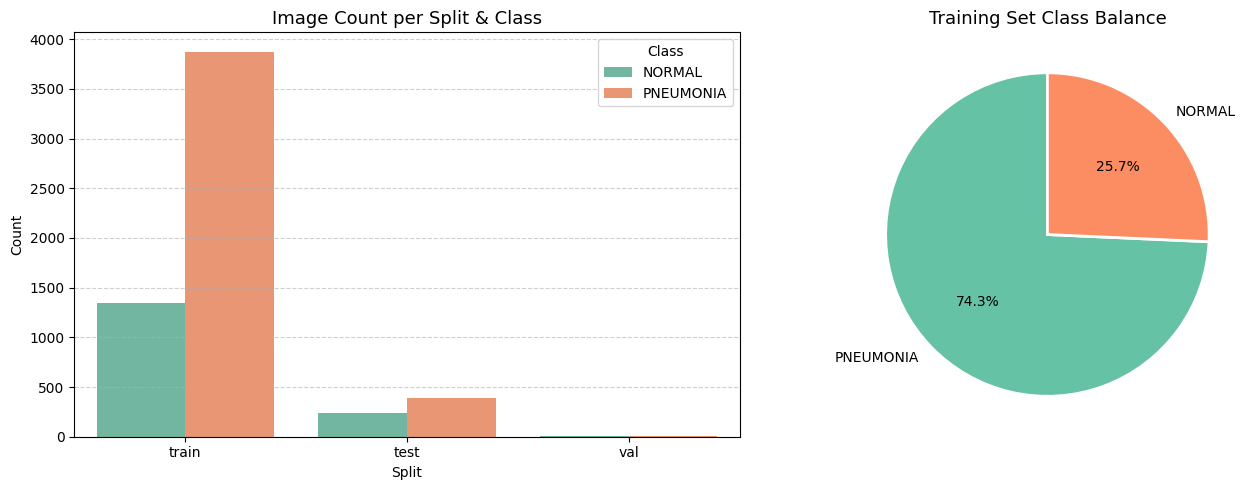

In [3]:
data_rows = []
for split in ['train', 'test', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(BASE_DIR, split, cls)
        if os.path.exists(folder):
            for f in os.listdir(folder):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data_rows.append({'Split': split, 'Class': cls,
                                      'Path': os.path.join(folder, f)})

df = pd.DataFrame(data_rows)
print(pd.crosstab(df['Split'], df['Class'], margins=True, margins_name='Total'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Split', hue='Class', palette='Set2', ax=axes[0])
axes[0].set_title('Image Count per Split & Class', fontsize=13)
axes[0].set_xlabel('Split'); axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

train_df = df[df['Split'] == 'train']
counts = train_df['Class'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#66c2a5','#fc8d62'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Training Set Class Balance', fontsize=13)
plt.tight_layout(); plt.show()

## Sample Image Visualization

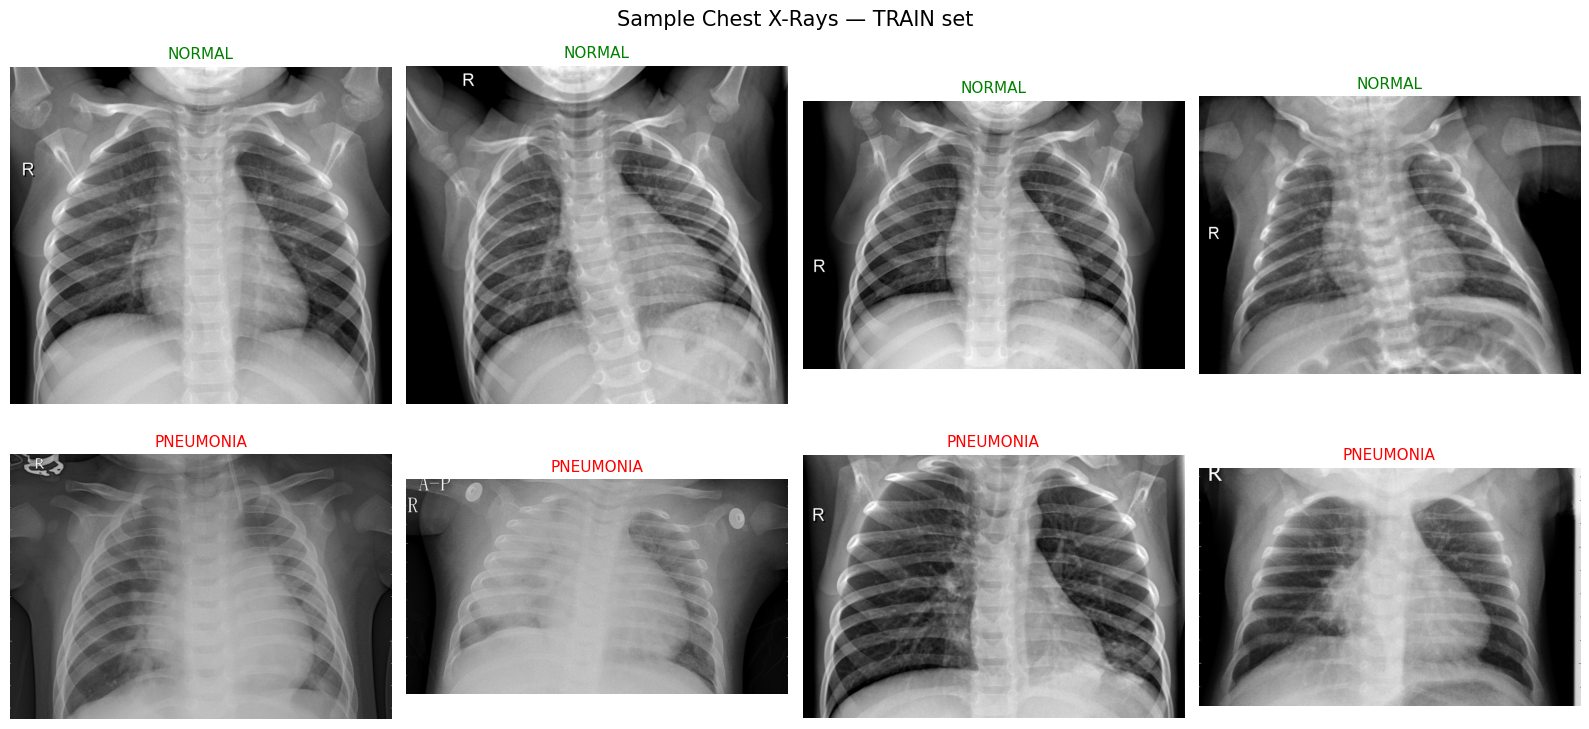

In [4]:
def show_sample_images(dataframe, split='train', num_samples=4):
    classes = ['NORMAL', 'PNEUMONIA']
    fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))
    fig.suptitle(f'Sample Chest X-Rays — {split.upper()} set', fontsize=15)
    for i, cls in enumerate(classes):
        sub = dataframe[(dataframe['Split'] == split) & (dataframe['Class'] == cls)]
        paths = sub['Path'].sample(min(num_samples, len(sub)), random_state=SEED).values
        for j, p in enumerate(paths):
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].set_title(cls, fontsize=11, color='green' if cls=='NORMAL' else 'red')
            axes[i, j].axis('off')
    plt.tight_layout(); plt.show()

show_sample_images(df)

## Preprocessing Techniques

**Techniques applied:**
- Resize to 224×224 (model requirement)
- Grayscale → RGB conversion (X-rays are grayscale; models expect 3-channel)
- CLAHE (Contrast Limited Adaptive Histogram Equalization) — enhances local contrast
- Gaussian Blur (mild denoising)
- Normalization with ImageNet mean/std (required for pretrained weights)
- Center Crop (removes irrelevant border artifacts)
- ToTensor conversion

In [5]:
# ── CLAHE helper (applied at image-load time) ──────────────────────────────────
class CLAHETransform:
    """Apply CLAHE to each channel of a PIL Image."""
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)

    def __call__(self, img: Image.Image) -> Image.Image:
        img_np = np.array(img)                     # H x W x 3, uint8
        lab    = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self.clahe.apply(lab[:, :, 0])
        result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(result)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Baseline preprocessing (NO augmentation) ─────────────────────────────────
baseline_transform = transforms.Compose([
    transforms.Resize((256, 256)),                        # Step 1: upscale slightly
    transforms.CenterCrop(224),                           # Step 2: center crop to 224
    transforms.Lambda(lambda img: img.convert('RGB')),    # Step 3: grayscale → 3ch
    CLAHETransform(clip_limit=2.0),                       # Step 4: CLAHE
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # Step 5: mild denoise
    transforms.ToTensor(),                                # Step 6: HWC → CHW float
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),    # Step 7: standardize
])

# ── Augmented preprocessing (for training only) ───────────────────────────────
augmented_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda img: img.convert('RGB')),
    CLAHETransform(clip_limit=2.0),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    # ── Augmentation block ────────────────────────────────────────────────────
    transforms.RandomHorizontalFlip(p=0.5),               # Aug 1: horizontal flip
    transforms.RandomVerticalFlip(p=0.1),                 # Aug 2: vertical flip (rare)
    transforms.RandomRotation(degrees=15),                # Aug 3: small rotation
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Aug 4: slight shift
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # Aug 5: brightness/contrast
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.4),  # Aug 6: sharpness
    transforms.RandomAutocontrast(p=0.3),                  # Aug 7: auto contrast
    # ─────────────────────────────────────────────────────────────────────────
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),   # Aug 8: cutout/erasing
])

# Validation/test transform — no augmentation
val_transform = baseline_transform

print('Transforms defined.')
print(f'  Baseline  : {len(baseline_transform.transforms)} steps')
print(f'  Augmented : {len(augmented_transform.transforms)} steps')

Transforms defined.
  Baseline  : 7 steps
  Augmented : 15 steps


## Preprocessing Visualization

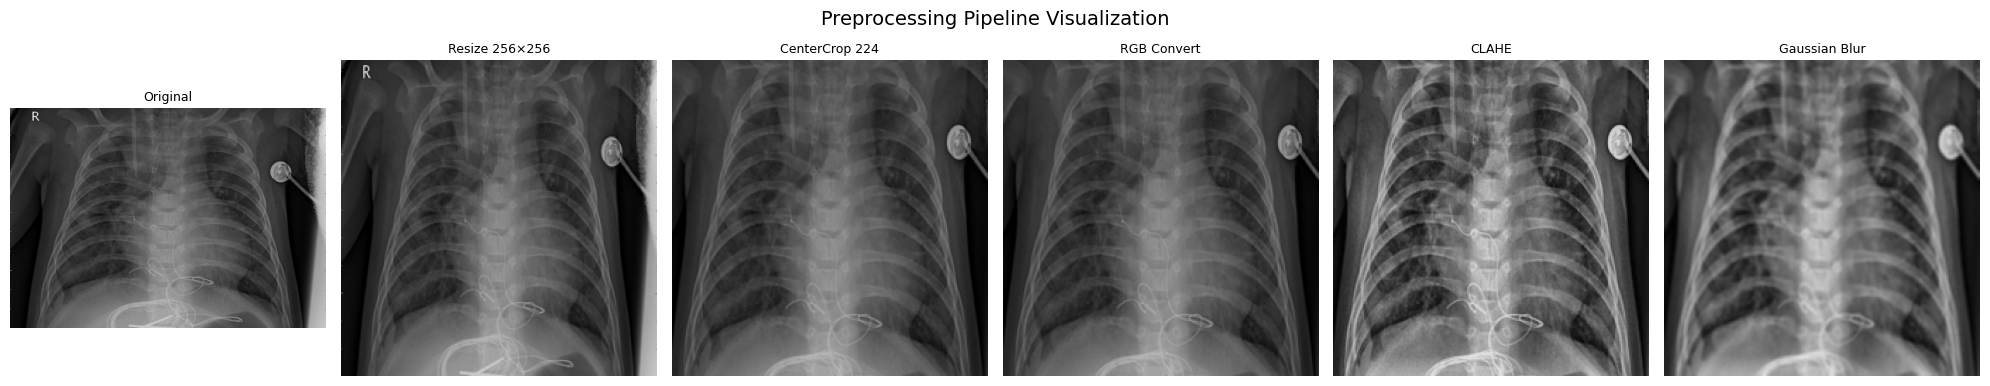

In [6]:
def visualize_preprocessing(img_path):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)

    # Steps
    resized   = pil_img.resize((256, 256))
    cropped   = TF.center_crop(resized, 224)
    rgb3ch    = cropped.convert('RGB')
    clahe_img = CLAHETransform()(rgb3ch)
    blurred   = transforms.GaussianBlur(3)(clahe_img)

    steps = [
        ('Original', img_rgb),
        ('Resize 256×256', np.array(resized)),
        ('CenterCrop 224', np.array(cropped)),
        ('RGB Convert',    np.array(rgb3ch)),
        ('CLAHE',          np.array(clahe_img)),
        ('Gaussian Blur',  np.array(blurred)),
    ]

    fig, axes = plt.subplots(1, len(steps), figsize=(20, 4))
    fig.suptitle('Preprocessing Pipeline Visualization', fontsize=14)
    for ax, (title, img) in zip(axes, steps):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

sample_path = df[(df['Split']=='train') & (df['Class']=='PNEUMONIA')]['Path'].iloc[0]
visualize_preprocessing(sample_path)

## Augmentation Visualization

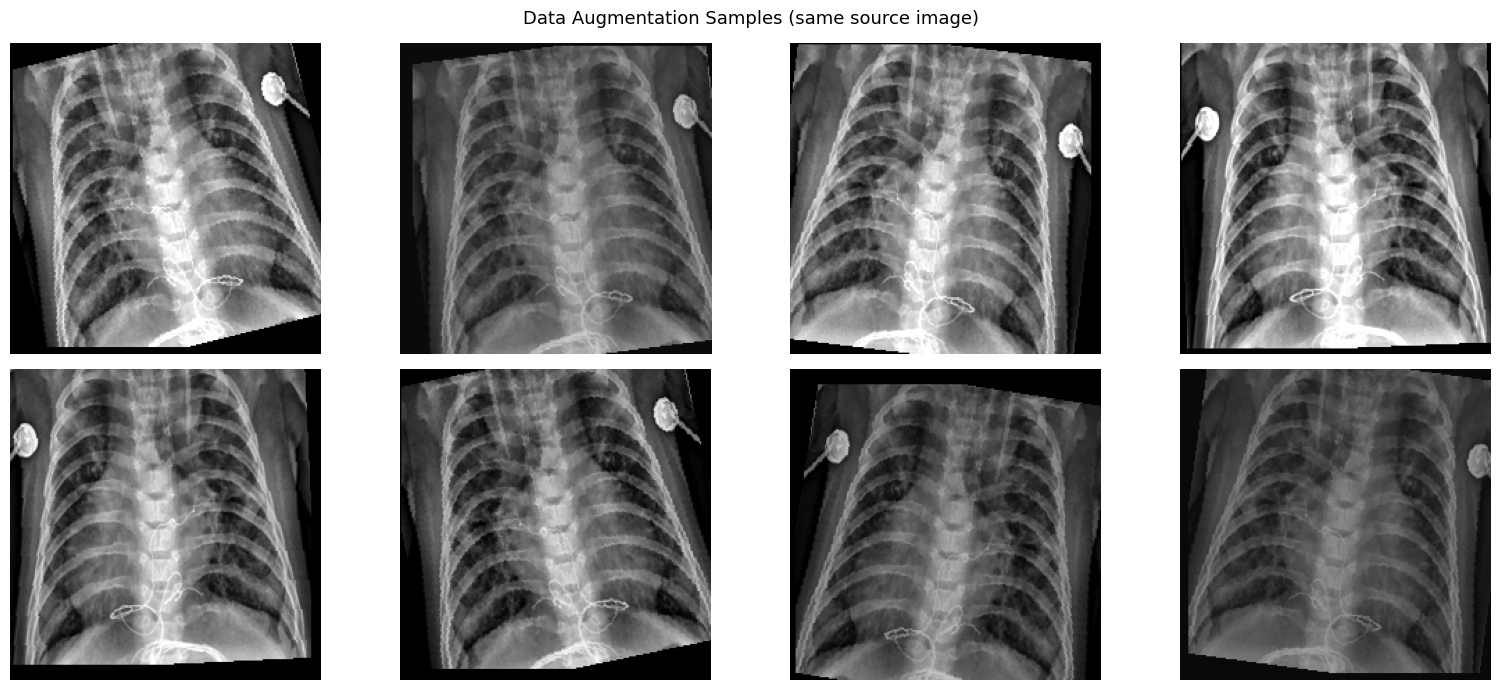

In [7]:
def visualize_augmentation(img_path, n=8):
    pil_img = Image.open(img_path).convert('RGB')

    # Augmentation-only pipeline (no normalize for display)
    aug_display = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.Lambda(lambda i: i.convert('RGB')),
        CLAHETransform(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.RandomRotation(15),
        transforms.RandomAffine(0, translate=(0.05, 0.05)),
        transforms.ColorJitter(0.3, 0.3),
    ])

    fig, axes = plt.subplots(2, n//2, figsize=(16, 7))
    fig.suptitle('Data Augmentation Samples (same source image)', fontsize=13)
    for ax in axes.flat:
        aug = aug_display(pil_img)
        ax.imshow(aug); ax.axis('off')
    plt.tight_layout(); plt.show()

visualize_augmentation(sample_path)

## DataLoaders

In [8]:
def is_valid_file(path):
    return path.lower().endswith(('.png', '.jpg', '.jpeg'))

BATCH_SIZE = 32
NUM_WORKERS = 4

def make_loaders(train_tf):
    train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf,
                                    is_valid_file=is_valid_file)
    test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_transform,
                                    is_valid_file=is_valid_file)
    val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_transform,
                                    is_valid_file=is_valid_file)

    # Weighted sampler to handle class imbalance
    targets = train_ds.targets
    class_counts = np.bincount(targets)
    weights = 1.0 / class_counts
    sample_weights = torch.tensor([weights[t] for t in targets], dtype=torch.float)
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    print(f'Train: {len(train_ds)} | Test: {len(test_ds)} | Val: {len(val_ds)}')
    print(f'Classes: {train_ds.classes}')
    return train_loader, test_loader, val_loader, train_ds


# ── Baseline loaders (no augmentation) ────────────────────────────────────────
print('=== Baseline DataLoaders ===')
train_loader_base, test_loader, val_loader, train_ds = make_loaders(baseline_transform)

# ── Augmented loaders ─────────────────────────────────────────────────────────
print('\n=== Augmented DataLoaders ===')
train_loader_aug, _, _, _ = make_loaders(augmented_transform)

NUM_CLASSES = 2
CLASS_NAMES = train_ds.classes

=== Baseline DataLoaders ===
Train: 5216 | Test: 624 | Val: 16
Classes: ['NORMAL', 'PNEUMONIA']

=== Augmented DataLoaders ===
Train: 5216 | Test: 624 | Val: 16
Classes: ['NORMAL', 'PNEUMONIA']


## 8. Training Utilities

In [9]:
# ── Training loop ─────────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=10,
                lr=1e-4, label='Model', patience=3):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': [],
               'epoch_times': []}

    best_val_acc   = 0.0
    best_weights   = None
    no_improve     = 0
    total_start    = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        # ── Train phase ───────────────────────────────────────────────────────
        model.train()
        t_loss = t_correct = t_total = 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item()
            preds      = out.argmax(1)
            t_correct += (preds == y).sum().item()
            t_total   += y.size(0)

        scheduler.step()
        train_loss = t_loss / len(train_loader)
        train_acc  = t_correct / t_total

        # ── Val phase ─────────────────────────────────────────────────────────
        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out  = model(X)
                loss = criterion(out, y)
                v_loss    += loss.item()
                preds      = out.argmax(1)
                v_correct += (preds == y).sum().item()
                v_total   += y.size(0)

        val_loss = v_loss / len(val_loader)
        val_acc  = v_correct / v_total
        ep_time  = time.time() - ep_start

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_times'].append(ep_time)

        print(f'[{label}] Epoch {epoch+1:02d}/{epochs} | '
              f'TrLoss: {train_loss:.4f} TrAcc: {train_acc:.4f} | '
              f'VaLoss: {val_loss:.4f} VaAcc: {val_acc:.4f} | '
              f'Time: {ep_time:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  → Early stopping at epoch {epoch+1}')
                break

    total_time = time.time() - total_start
    history['total_time'] = total_time
    history['avg_epoch_time'] = np.mean(history['epoch_times'])
    model.load_state_dict(best_weights)
    print(f'  Best Val Acc: {best_val_acc:.4f} | Total Time: {total_time:.1f}s')
    return model, history


# ── Evaluation on test set ────────────────────────────────────────────────────
def evaluate_model(model, test_loader, model_name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(DEVICE)
            out   = model(X)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec  = recall_score(all_labels, all_preds, average='weighted')
    f1   = f1_score(all_labels, all_preds, average='weighted')
    cm   = confusion_matrix(all_labels, all_preds)

    # Model size (MB)
    save_path = f'/tmp/{model_name}_tmp.pth'
    torch.save(model.state_dict(), save_path)
    size_mb = os.path.getsize(save_path) / (1024**2)

    # Parameter count
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'Confusion Matrix': cm,
        'Model Size (MB)': round(size_mb, 2),
        'Total Params (M)': round(total_params / 1e6, 2),
        'Trainable Params (M)': round(trainable_params / 1e6, 2),
    }

    print(f'\n=== {model_name} Test Metrics ===')
    for k, v in metrics.items():
        if k != 'Confusion Matrix':
            print(f'  {k}: {v}')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    return metrics


# ── Confusion matrix plot ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, model_name, class_names=CLASS_NAMES):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.tight_layout(); plt.show()


# ── Loss & Accuracy curves ────────────────────────────────────────────────────
def plot_history(history, model_name):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', ms=5)
    axes[0].plot(epochs_range, history['val_loss'],   'r-s', label='Val Loss',   ms=5)
    axes[0].set_title('Loss vs Epochs'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)

    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', ms=5)
    axes[1].plot(epochs_range, history['val_acc'],   'r-s', label='Val Acc',   ms=5)
    axes[1].set_title('Accuracy vs Epochs'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout(); plt.show()

print('Utility functions ready.')

Utility functions ready.


# Swin Transformer (swin_base_patch4_window7_224)
Primary model — vision transformer with shifted window attention

In [10]:
def build_swin(num_classes=2, freeze_backbone=False):
    model = timm.create_model(
        'swin_base_patch4_window7_224',
        pretrained=True,
        num_classes=num_classes
    )
    if freeze_backbone:
        # Freeze all layers except the classifier head
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
    return model

print('Building Swin Transformer...')
swin_model = build_swin()
total = sum(p.numel() for p in swin_model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Building Swin Transformer...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Total parameters: 86.75M


In [11]:
# ── Train on BASELINE (no augmentation) ──────────────────────────────────────
print('\n>>> Training Swin Transformer — Baseline (no augmentation) <<<')
swin_model, swin_history = train_model(
    swin_model, train_loader_base, test_loader,
    epochs=10, lr=1e-4, label='Swin-Base', patience=4
)
torch.save(swin_model.state_dict(), '/kaggle/working/swin_baseline.pth')


>>> Training Swin Transformer — Baseline (no augmentation) <<<
[Swin-Base] Epoch 01/10 | TrLoss: 0.1579 TrAcc: 0.9363 | VaLoss: 0.2090 VaAcc: 0.9295 | Time: 214.8s
[Swin-Base] Epoch 02/10 | TrLoss: 0.0520 TrAcc: 0.9839 | VaLoss: 0.2904 VaAcc: 0.9151 | Time: 227.1s
[Swin-Base] Epoch 03/10 | TrLoss: 0.0326 TrAcc: 0.9896 | VaLoss: 0.3037 VaAcc: 0.9022 | Time: 226.6s
[Swin-Base] Epoch 04/10 | TrLoss: 0.0265 TrAcc: 0.9910 | VaLoss: 0.7120 VaAcc: 0.8750 | Time: 227.6s
[Swin-Base] Epoch 05/10 | TrLoss: 0.0158 TrAcc: 0.9952 | VaLoss: 1.8561 VaAcc: 0.7756 | Time: 227.3s
  → Early stopping at epoch 5
  Best Val Acc: 0.9295 | Total Time: 1123.5s


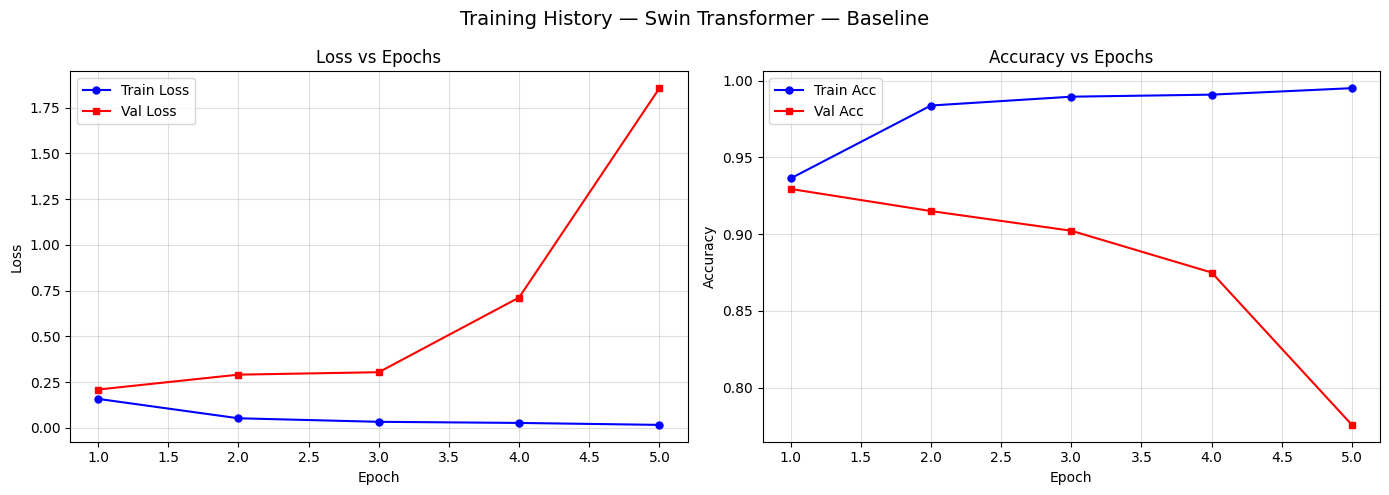


=== Swin-Baseline Test Metrics ===
  Accuracy: 0.9214743589743589
  Precision: 0.9221282683938179
  Recall: 0.9214743589743589
  F1: 0.920659159272386
  Model Size (MB): 331.03
  Total Params (M): 86.75
  Trainable Params (M): 86.75

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.85      0.89       234
   PNEUMONIA       0.91      0.96      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



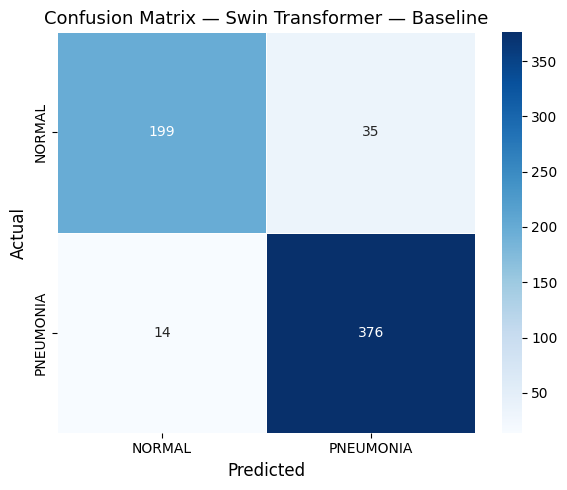

In [12]:
plot_history(swin_history, 'Swin Transformer — Baseline')
swin_metrics = evaluate_model(swin_model, test_loader, 'Swin-Baseline')
swin_metrics['Total Time (s)']   = round(swin_history['total_time'], 2)
swin_metrics['Avg Epoch Time (s)'] = round(swin_history['avg_epoch_time'], 2)
plot_confusion_matrix(swin_metrics['Confusion Matrix'], 'Swin Transformer — Baseline')

# Data Augmentation Experiments

In [13]:
print('\n' + '='*60)
print('AUGMENTATION EXPERIMENTS')
print('='*60)

# ── MODEL 1 (AUG): Swin Transformer ──────────────────────────────────────────
print('\n>>> Training Swin Transformer — WITH Augmentation <<<')
swin_aug_model = build_swin()
swin_aug_model, swin_aug_history = train_model(
    swin_aug_model, train_loader_aug, test_loader,
    epochs=10, lr=1e-4, label='Swin-Aug', patience=4
)
torch.save(swin_aug_model.state_dict(), '/kaggle/working/swin_augmented.pth')


AUGMENTATION EXPERIMENTS

>>> Training Swin Transformer — WITH Augmentation <<<
[Swin-Aug] Epoch 01/10 | TrLoss: 0.2202 TrAcc: 0.9030 | VaLoss: 0.3088 VaAcc: 0.8942 | Time: 229.0s
[Swin-Aug] Epoch 02/10 | TrLoss: 0.1137 TrAcc: 0.9567 | VaLoss: 0.2470 VaAcc: 0.9071 | Time: 226.6s
[Swin-Aug] Epoch 03/10 | TrLoss: 0.0808 TrAcc: 0.9720 | VaLoss: 0.3409 VaAcc: 0.9119 | Time: 226.5s
[Swin-Aug] Epoch 04/10 | TrLoss: 0.0625 TrAcc: 0.9760 | VaLoss: 0.5269 VaAcc: 0.8958 | Time: 227.3s
[Swin-Aug] Epoch 05/10 | TrLoss: 0.0463 TrAcc: 0.9810 | VaLoss: 0.5048 VaAcc: 0.8590 | Time: 227.1s
[Swin-Aug] Epoch 06/10 | TrLoss: 0.0408 TrAcc: 0.9854 | VaLoss: 0.2801 VaAcc: 0.9167 | Time: 227.9s
[Swin-Aug] Epoch 07/10 | TrLoss: 0.0373 TrAcc: 0.9858 | VaLoss: 0.7310 VaAcc: 0.8125 | Time: 226.5s
[Swin-Aug] Epoch 08/10 | TrLoss: 0.0364 TrAcc: 0.9870 | VaLoss: 0.5063 VaAcc: 0.8734 | Time: 227.2s
[Swin-Aug] Epoch 09/10 | TrLoss: 0.0268 TrAcc: 0.9916 | VaLoss: 0.5614 VaAcc: 0.8606 | Time: 227.9s
[Swin-Aug] Epoch 10

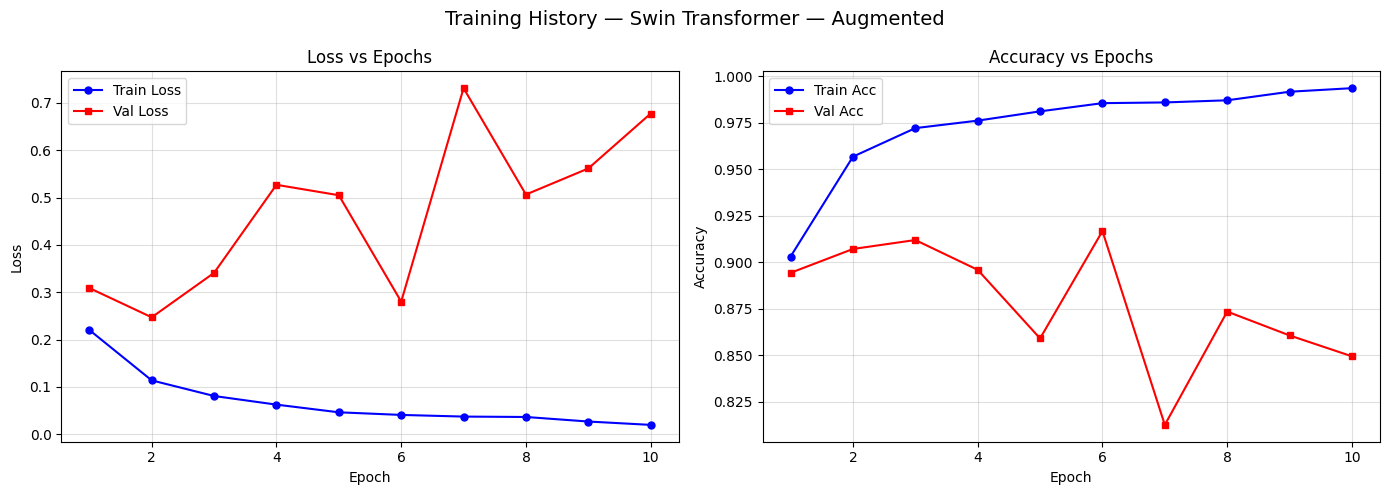


=== Swin-Augmented Test Metrics ===
  Accuracy: 0.9102564102564102
  Precision: 0.9161532864419113
  Recall: 0.9102564102564102
  F1: 0.9079959699578678
  Model Size (MB): 331.03
  Total Params (M): 86.75
  Trainable Params (M): 86.75

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.79      0.87       234
   PNEUMONIA       0.88      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.93      0.89      0.90       624
weighted avg       0.92      0.91      0.91       624



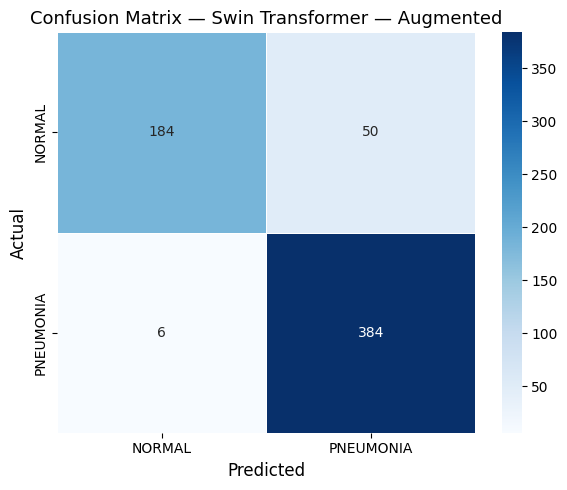

In [14]:
plot_history(swin_aug_history, 'Swin Transformer — Augmented')
swin_aug_metrics = evaluate_model(swin_aug_model, test_loader, 'Swin-Augmented')
swin_aug_metrics['Total Time (s)']     = round(swin_aug_history['total_time'], 2)
swin_aug_metrics['Avg Epoch Time (s)'] = round(swin_aug_history['avg_epoch_time'], 2)
plot_confusion_matrix(swin_aug_metrics['Confusion Matrix'], 'Swin Transformer — Augmented')